In [1]:
from field import Field
import os

In [2]:
def plot_segment(control_point, machine, leaf_width = 0.5, iso_x = 0, iso_y = 0):
    i = 0
    num_leaves = len(control_point["leafSetA"])

    if machine == "TrueBeam":
        start = -num_leaves//2*leaf_width
        end = start+ leaf_width
        while end < num_leaves/2*leaf_width- leaf_width:
            ax.vlines(iso_x + control_point['leafSetA'][i], iso_y + start,iso_y + end, color = "red")
            ax.hlines(iso_y + end, iso_x +control_point['leafSetA'][i], iso_x +control_point['leafSetA'][i+1], color = "red")
            ax.vlines(iso_x -control_point['leafSetB'][i], iso_y + start,iso_y + end, color = "red")
            ax.hlines(iso_y + end, iso_x -control_point['leafSetB'][i], iso_x-control_point['leafSetB'][i+1], color = "red")
        
            start += leaf_width
            end += leaf_width
            i += 1
    else:
        start = num_leaves//2*leaf_width
        end = start - leaf_width
        while end > -num_leaves/2*leaf_width+leaf_width:
            ax.vlines(iso_x + control_point['leafSetA'][i], iso_y + start,iso_y + end)
            ax.hlines(iso_y + end, iso_x +control_point['leafSetA'][i], iso_x +control_point['leafSetA'][i+1])
            ax.vlines(iso_x -control_point['leafSetB'][i], iso_y + start,iso_y + end)
            ax.hlines(iso_y + end, iso_x -control_point['leafSetB'][i], iso_x-control_point['leafSetB'][i+1])
            
            start -= leaf_width
            end -= leaf_width
            i += 1

    

In [3]:
import pandas as pd

df = pd.read_json(os.path.dirname(os.getcwd()) + "\\FieldsMetaData-2023-Nov-06.json")
df

,FieldID,QADate,Unit,Energy,MU,DPF,ADPass,RDPass,AD,RD,D4DD,D4DTA,D4Gamma
0,2392761,11/06/2023,EA05,6X,686.7,500,83,95,74.4,93.7,81.6,91.0,94.9
1,2392762,11/06/2023,EA05,6X,682.2,500,83,95,68.4,97.3,80.5,89.7,91.8
2,2393352,11/06/2023,EV06,6X,200.0,220,83,95,93.0,100.0,0.0,0.0,0.0
3,2392987,11/06/2023,EV06,6X,683.0,500,85,95,98.3,99.6,0.0,0.0,0.0
4,2393164,11/06/2023,EV06,6X,560.0,500,85,95,99.4,99.9,0.0,0.0,0.0
5,2393165,11/06/2023,EV06,6X,296.0,500,85,95,99.9,100.0,0.0,0.0,0.0
6,2393320,11/06/2023,EV06,6X,660.0,400,85,95,95.5,100.0,0.0,0.0,0.0
7,2393351,11/06/2023,EV06,6X,200.0,220,83,95,98.0,99.9,0.0,0.0,0.0
8,2393350,11/06/2023,EV06,6X,225.0,220,83,95,95.7,99.6,0.0,0.0,0.0
9,2392906,11/06/2023,EV06,6X,632.0,500,85,95,96.4,98.6,0.0,0.0,0.0


In [4]:
file = os.path.dirname(os.getcwd()) + "\\Nov6\\" + "FieldID_2393324.json"
field = Field(file)


## Plotting Segment vs Rotated Boundary

In [1]:
import math
from Calc_Span import span
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'Calc_Span'

In [23]:
def calcAlpha(ordinate, abscissa):
    # the 'ordinate' is the vertical, the 'abscissa' is the horizontal axis
    
    if ordinate == 0 and abscissa == 0:
        alpha = 0
    elif ordinate > 0 and abscissa == 0:
        alpha = 90
    elif ordinate < 0 and abscissa == 0:
        alpha = 270
    
    elif ordinate >= 0 and abscissa > 0:
        alpha= math.degrees(math.atan(ordinate/abscissa))
    elif ordinate >= 0 and abscissa < 0:
        alpha= math.degrees(math.atan(ordinate/abscissa)) + 180
    elif ordinate <= 0 and abscissa < 0:
        alpha= math.degrees(math.atan(ordinate/abscissa)) + 180    
    elif ordinate <= 0 and abscissa > 0:
        alpha= math.degrees(math.atan(ordinate/abscissa)) + 360
    
    return alpha
    
    

def span(machine_type, collimatorAngle, X1, X2, Y1 = None, Y2 = None):

    # machine_type == Agility: X1, X2 are the "top" and "bottom" jaws, "Y1" and "Y2" are the imaginary left and right jaws (to be replaced by the maxima of LeafbankB and LeafbankA respectively)

    if machine_type == "Agility":
    
        alpha1 = calcAlpha(Y1, X1) #UR
        alpha2 = calcAlpha(-Y2, X1)  #UL
        alpha3 = calcAlpha(-Y2, -X2) #BL
        alpha4 = calcAlpha(Y1, -X2) #BR
        
        radius2 = math.sqrt(math.pow(X1,2)+math.pow(Y2,2)) #UR
        radius1 = math.sqrt(math.pow(X1,2)+math.pow(-Y1,2)) #UL
        radius4 = math.sqrt(math.pow(-X2,2)+math.pow(-Y1,2)) #BL
        radius3 = math.sqrt(math.pow(-X2,2)+math.pow(Y2,2)) #BR
        
    elif machine_type == "TrueBeam":
        alpha1 = calcAlpha(X2, Y2) #UR
        alpha2 = calcAlpha(-X1, Y2)  #UL
        alpha3 = calcAlpha(-X1, -Y1) #BL
        alpha4 = calcAlpha(X2, -Y1) #BR
        
        radius1 = math.sqrt(math.pow(Y2,2)+math.pow(X2,2)) #UR
        radius2 = math.sqrt(math.pow(Y2,2)+math.pow(-X1,2)) #UL
        radius3 = math.sqrt(math.pow(-Y1,2)+math.pow(-X1,2)) #BL
        radius4 = math.sqrt(math.pow(-Y1,2)+math.pow(X2,2)) #BR
        #print(alpha1, alpha2, alpha3, alpha4)
        #print(radius1, radius2, radius3, radius4)
        
        
    ### calculate the rotated field edges
    # collimatorAngle needs to be in radians units
    UR_rotated = [radius1*math.cos(math.radians(alpha1)+collimatorAngle), radius1*math.sin(math.radians(alpha1)+collimatorAngle)]
    UL_rotated = [radius2*math.cos(math.radians(alpha2)+collimatorAngle), radius2*math.sin(math.radians(alpha2)+collimatorAngle)]
    BL_rotated = [radius3*math.cos(math.radians(alpha3)+collimatorAngle), radius3*math.sin(math.radians(alpha3)+collimatorAngle)]
    BR_rotated = [radius4*math.cos(math.radians(alpha4)+collimatorAngle), radius4*math.sin(math.radians(alpha4)+collimatorAngle)]
    
    field_rotated = [UR_rotated, UL_rotated, BL_rotated, BR_rotated]
    field_rotated_ordinate = [corner[1] for corner in field_rotated]
    
    span = max(field_rotated_ordinate) - min(field_rotated_ordinate)
        #print('span = ', span)
        
    return field_rotated

In [ ]:
n = 0
cp = field.mq_control_points[n]

X1 = cp['collimatorX1']
X2 = cp['collimatorX2']
collimatorAngle =  math.radians(cp['collimatorAngle'])
Y1 = max(cp['leafSetA'])
Y2 = max(cp["leafSetB"])
gantry = cp["gantryAngle"]


field_rotated = span("Agility", collimatorAngle, X1, X2, Y1 = Y1, Y2 = Y2)


In [ ]:
field_rotated

[[2.761134173019535, 5.150120200401513],
 [5.144857578413749, -3.746056659720807],
 [-3.06551194504333, -5.946018543092231],
 [-5.4492353504375455, 2.950158317030088]]

In [ ]:
field_unrotated = [[Y1,X1], [-Y2,X1], [-Y2,-X2], [Y1,-X2]]
field_unrotated

[[4.26, 4], [-4.95, 4], [-4.95, -4.5], [4.26, -4.5]]

In [86]:
for i in range(4):
    rotated_radius = math.sqrt(field_rotated[i][0]**2 + field_rotated[i][1]**2)
    unrotated_radius = math.sqrt(field_unrotated[i][0]**2 + field_unrotated[i][1]**2)
    print("Rotated radius:   ", rotated_radius)
    print("Unrotated radius: ", unrotated_radius)
    print("------------------------------")

Rotated radius:    5.843594784034909
Unrotated radius:  5.843594784034909
------------------------------
Rotated radius:    6.3641574461982
Unrotated radius:  6.3641574461982
------------------------------
Rotated radius:    6.689730936293328
Unrotated radius:  6.689730936293327
------------------------------
Rotated radius:    6.196579701738694
Unrotated radius:  6.196579701738694
------------------------------


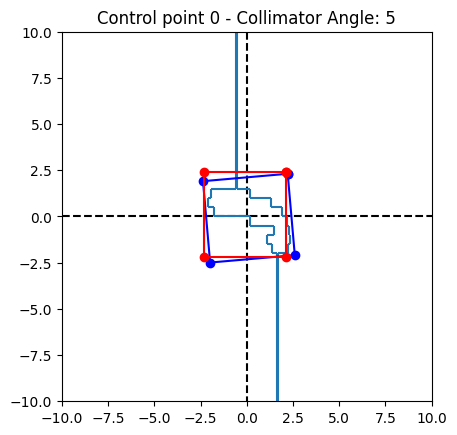

In [20]:
fig, ax = plt.subplots()
ax.plot([0, 0], [10, -10], '--', color='black')
ax.plot([-10,10], [0, 0], '--', color='black') 
ax.set_aspect('equal')

plot_segment(cp, "Agility", field.leaf_width)

field_rotated_abscissa = [corner[0] for corner in field_rotated]
field_rotated_ordinate = [corner[1] for corner in field_rotated]

field_unrotated_abscissa = [corner[0] for corner in field_unrotated]
field_unrotated_ordinate = [corner[1] for corner in field_unrotated]
ax.plot(field_rotated_abscissa+[field_rotated_abscissa[0]], field_rotated_ordinate+[field_rotated_ordinate[0]], 'bo-')
ax.plot(field_unrotated_abscissa+[field_unrotated_abscissa[0]], field_unrotated_ordinate+[field_unrotated_ordinate[0]], 'ro-')

plt.title("Control point {} - Collimator Angle: {}".format(gantry, cp["collimatorAngle"]))

plt.xlim((-10,10))
plt.ylim((-10,10))

plt.show()

## Plot Mulitple Segments

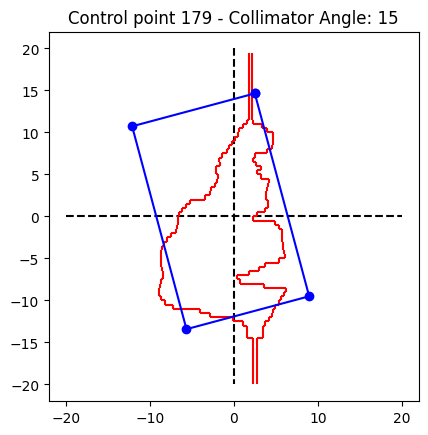

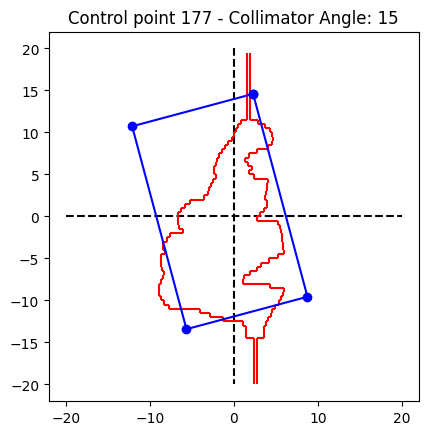

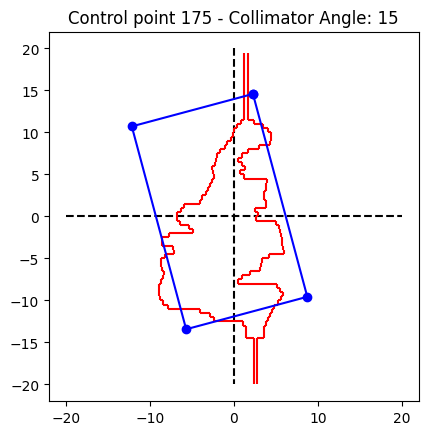

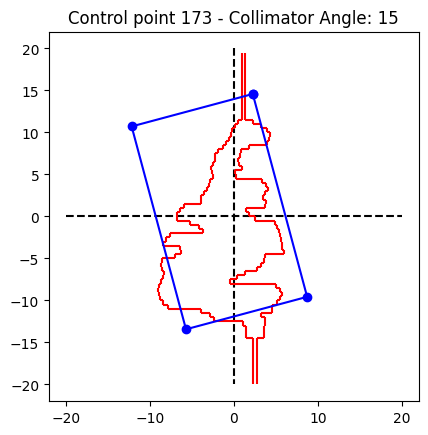

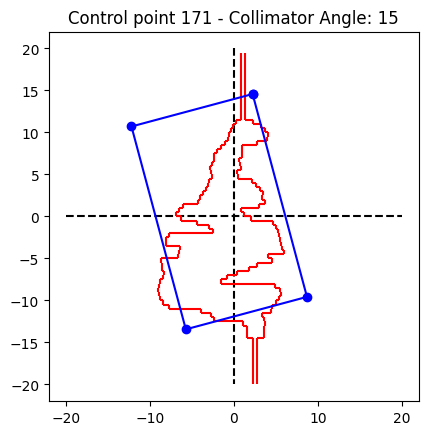

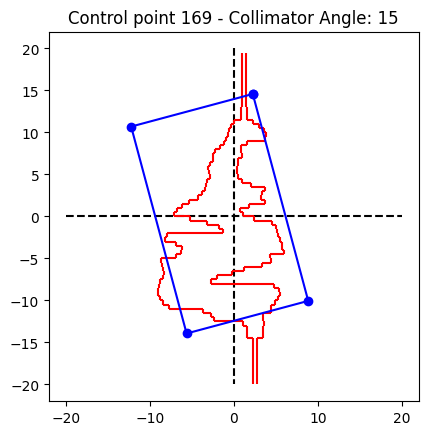

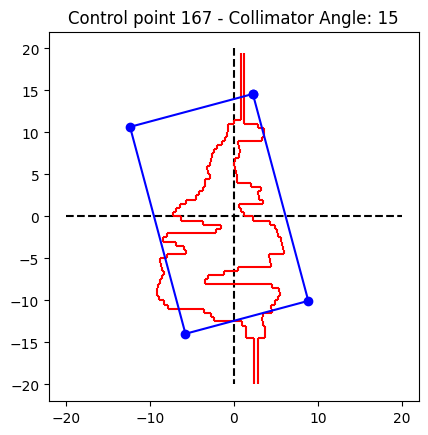

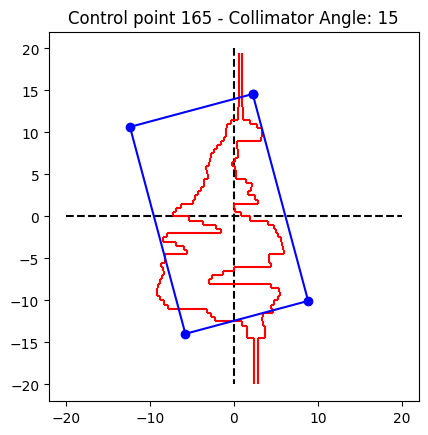

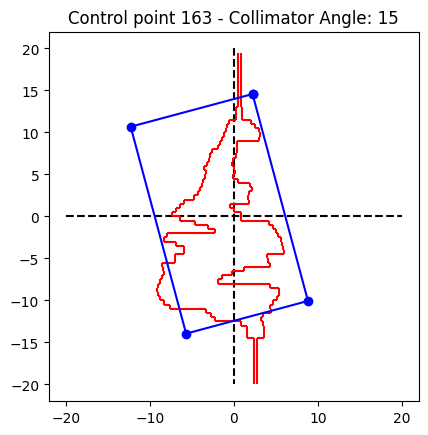

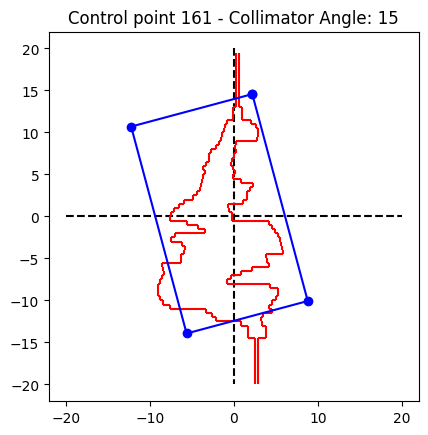

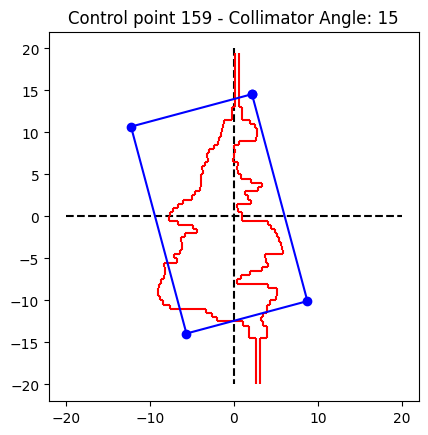

In [52]:
for n in range(len(field.mq_control_points)):
    cp = field.mq_control_points[n]

    X1 = cp['collimatorX1']
    X2 = cp['collimatorX2']
    collimatorAngle = math.radians(cp['collimatorAngle'])
    Y1 = max(cp['leafSetA'])
    Y2 = max(cp["leafSetB"])
    gantry = cp["gantryAngle"]


    field_rotated = span("Agility", collimatorAngle, X1, X2, Y1 = Y1, Y2 = Y2)

    fig, ax = plt.subplots()
    ax.plot([0, 0], [20, -20], '--', color='black')
    ax.plot([-20, 20], [0, 0], '--', color='black') 
    ax.set_aspect('equal')

    plot_segment(cp, "Agility", field.leaf_width)

    field_rotated_abscissa = [corner[0] for corner in field_rotated]
    field_rotated_ordinate = [corner[1] for corner in field_rotated]
    ax.plot(field_rotated_abscissa+[field_rotated_abscissa[0]], field_rotated_ordinate+[field_rotated_ordinate[0]], 'bo-')

    plt.title("Control point {} - Collimator Angle: {}".format(gantry, cp["collimatorAngle"]))

    plt.show()

    if n == 10:
        break

In [44]:
field_rotated_list = []
cp_list = []
span_list = []

for n in range(len(field.mq_control_points)):
    cp = field.mq_control_points[n]

    X1 = cp['collimatorX1']
    X2 = cp['collimatorX2']
    collimatorAngle = math.radians(cp['collimatorAngle'])
    Y1 = max(cp['leafSetA'])
    Y2 = max(cp["leafSetB"])
    gantry = cp["gantryAngle"]


    field_rotated = span("Agility", collimatorAngle, X1, X2, Y1 = Y1, Y2 = Y2)

    field_rotated_ordinate = [corner[1] for corner in field_rotated]
        
    span_val = max(field_rotated_ordinate) - min(field_rotated_ordinate)
        
    span_list.append(span_val)
    cp_list.append(n)
    field_rotated_list.append(field_rotated)
    

In [45]:
max_index = span_list.index(max(span_list))
max_span = span_list[max_index]
max_gantry = cp_list[max_index]
max_field_rotated = field_rotated_list[max_index]

min_index = span_list.index(min(span_list))
min_span = span_list[min_index]
min_gantry = cp_list[min_index]
min_field_rotated = field_rotated_list[min_index]

In [18]:
# Plot largest and smallest span
iso_x = 0
iso_y = 0
leaf_width = field.leaf_width
num_leaves = len(cp["leafSetA"])

min_cp = field.mq_control_points[min_gantry]

fig, ax = plt.subplots()
ax.plot([0, 0], [20, -20], '--', color='black')
ax.plot([-20, 20], [0, 0], '--', color='black') 
ax.set_aspect('equal')

plot_segment(min_cp, "Agility", field.leaf_width)

field_rotated_abscissa = [corner[0] for corner in min_field_rotated]
field_rotated_ordinate = [corner[1] for corner in min_field_rotated]
ax.plot(field_rotated_abscissa+[field_rotated_abscissa[0]], field_rotated_ordinate+[field_rotated_ordinate[0]], 'bo-')

plt.title("Smallest Span @ Gantry {} - Span: {:.2f} (ColAngle: {:.0f})".format(min_cp["gantryAngle"], min_span, min_cp['collimatorAngle']))

plt.show()

max_cp = field.mq_control_points[max_gantry]

fig, ax = plt.subplots()
ax.plot([0, 0], [20, -20], '--', color='black')
ax.plot([-20, 20], [0, 0], '--', color='black') 
ax.set_aspect('equal')

plot_segment(max_cp, "Agility", field.leaf_width)

field_rotated_abscissa = [corner[0] for corner in max_field_rotated]
field_rotated_ordinate = [corner[1] for corner in max_field_rotated]
ax.plot(field_rotated_abscissa+[field_rotated_abscissa[0]], field_rotated_ordinate+[field_rotated_ordinate[0]], 'bo-')

plt.title("Largest Span @ Gantry {} - Span: {:.2f} (ColAngle: {:.0f})".format(max_cp["gantryAngle"], max_span, max_cp['collimatorAngle']))

plt.show()

NameError: name 'min_gantry' is not defined

## Varian Machines

First let's create a function for plotting segments

In [8]:
import os, math
from field import Field
import matplotlib.pyplot as plt
from Calc_Span import span

In [9]:
# Load new varian field

file = os.path.dirname(os.getcwd()) + "\\Nov6\\" + "FieldID_2392987.json"
varian_field = Field(file)

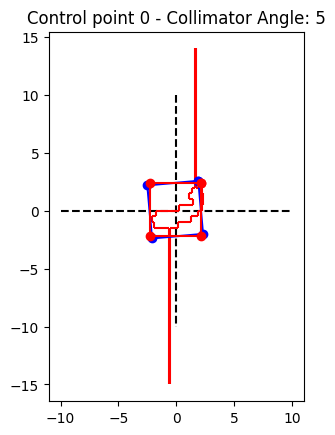

In [24]:
# Try plotting one segment

n = 0
cp = varian_field.mq_control_points[n]

X1 = cp['collimatorX1']
X2 = cp['collimatorX2']
collimatorAngle = math.radians(cp['collimatorAngle'])
Y1 = max(cp['leafSetA'])
Y2 = max(cp["leafSetB"])
gantry = cp["gantryAngle"]

field_unrotated = [[Y2,X2],[-Y1,X2], [-Y1,-X1], [Y2,-X1]]
field_unrotated
field_unrotated_abscissa = [corner[0] for corner in field_unrotated]
field_unrotated_ordinate = [corner[1] for corner in field_unrotated]

field_rotated = span("TrueBeam", collimatorAngle, X1, X2, Y1 = Y1, Y2 = Y2)
fig, ax = plt.subplots()
ax.plot([0, 0], [10, -10], '--', color='black')
ax.plot([-10, 10], [0, 0], '--', color='black') 
ax.set_aspect('equal')

plot_segment(cp,"TrueBeam", varian_field.leaf_width)

field_rotated_abscissa = [corner[0] for corner in field_rotated]
field_rotated_ordinate = [corner[1] for corner in field_rotated]
ax.plot(field_rotated_abscissa+[field_rotated_abscissa[0]], field_rotated_ordinate+[field_rotated_ordinate[0]], 'bo-')
ax.plot(field_unrotated_abscissa+[field_unrotated_abscissa[0]], field_unrotated_ordinate+[field_unrotated_ordinate[0]], 'ro-')


plt.title("Control point {} - Collimator Angle: {}".format(gantry, cp["collimatorAngle"]))

plt.show()


In [22]:
for i in range(4):
    rotated_radius = math.sqrt(field_rotated[i][0]**2 + field_rotated[i][1]**2)
    unrotated_radius = math.sqrt(field_unrotated[i][0]**2 + field_unrotated[i][1]**2)
    print("Rotated radius:   ", rotated_radius)
    print("Unrotated radius: ", unrotated_radius)
    print("------------------------------")

Rotated radius:    3.195637651549374
Unrotated radius:  3.195637651549374
------------------------------
Rotated radius:    3.048294605185004
Unrotated radius:  3.331080905652098
------------------------------
Rotated radius:    3.1900000000000004
Unrotated radius:  3.1900000000000004
------------------------------
Rotated radius:    3.331080905652098
Unrotated radius:  3.048294605185004
------------------------------


In [18]:
field_rotated

[[2.2069686582226304, 2.311144595567962],
 [-2.375526952999399, 1.9102281789287352],
 [-1.9902985700547509, -2.4929523866367798],
 [2.592197041167279, -2.092035969997553]]

In [15]:
field_unrotated

[[2.11, 2.4], [2.11, -2.2], [-2.31, -2.2], [-2.31, 2.4]]

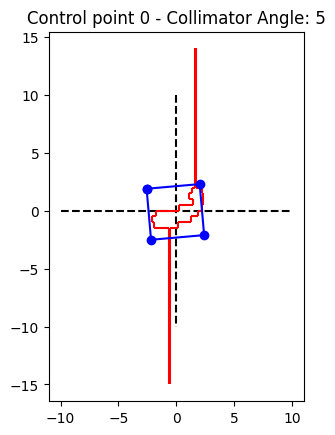

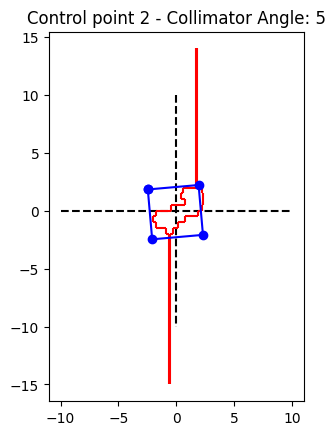

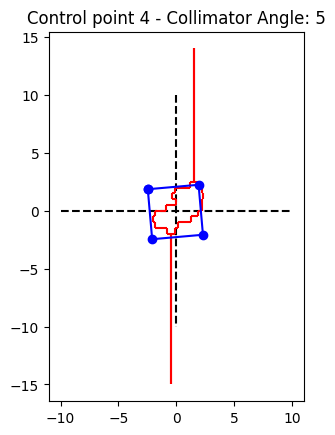

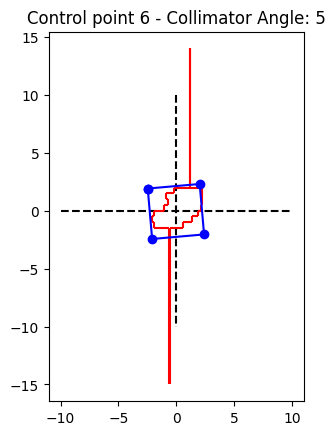

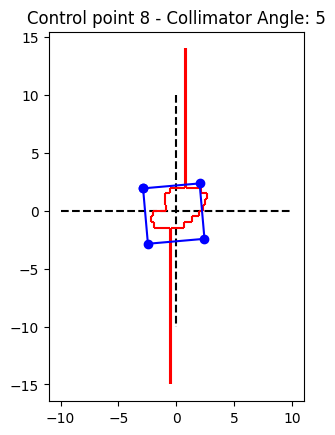

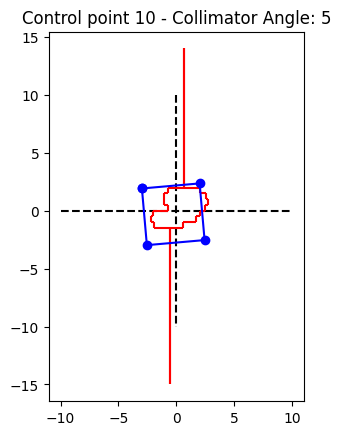

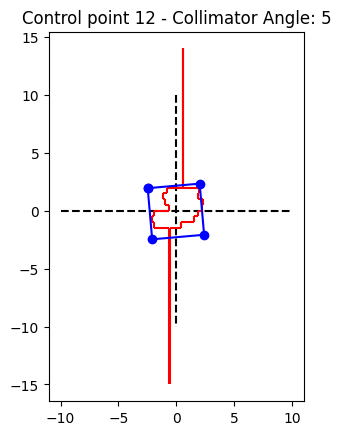

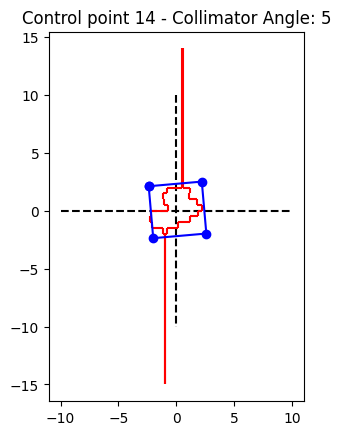

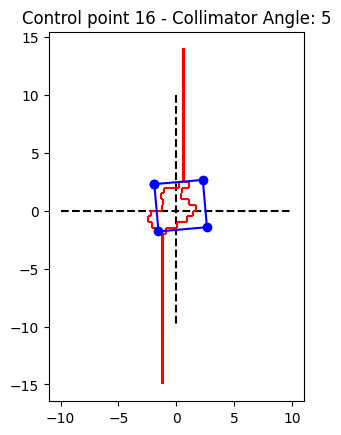

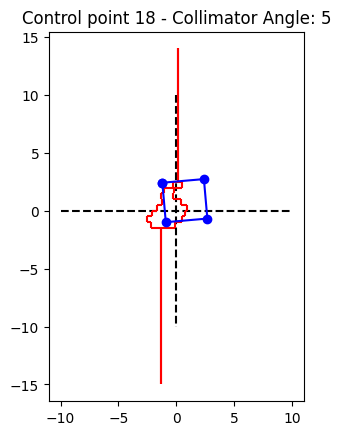

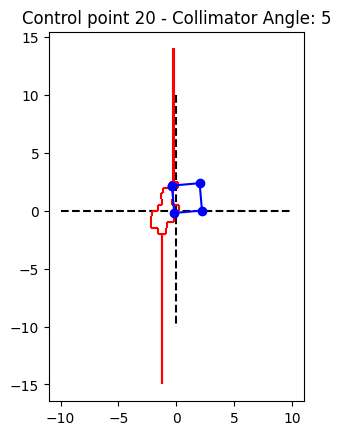

In [52]:
# multiple segments
for n in range(len(varian_field.mq_control_points)):
    cp = varian_field.mq_control_points[n]

    X1 = cp['collimatorX1']
    X2 = cp['collimatorX2']
    collimatorAngle = math.radians(cp['collimatorAngle'])
    Y1 = max(cp['leafSetA'])
    Y2 = max(cp["leafSetB"])
    gantry = cp["gantryAngle"]


    field_rotated = span("TrueBeam", collimatorAngle, X1, X2, Y1 = Y1, Y2 = Y2)

    fig, ax = plt.subplots()
    ax.plot([0, 0], [10, -10], '--', color='black')
    ax.plot([-10, 10], [0, 0], '--', color='black') 
    ax.set_aspect('equal')

    plot_segment(cp, "TrueBeam", varian_field.leaf_width)

    field_rotated_abscissa = [corner[0] for corner in field_rotated]
    field_rotated_ordinate = [corner[1] for corner in field_rotated]
    ax.plot(field_rotated_abscissa+[field_rotated_abscissa[0]], field_rotated_ordinate+[field_rotated_ordinate[0]], 'bo-')

    plt.title("Control point {} - Collimator Angle: {}".format(gantry, cp["collimatorAngle"]))

    plt.show()

    if n == 10:
        break

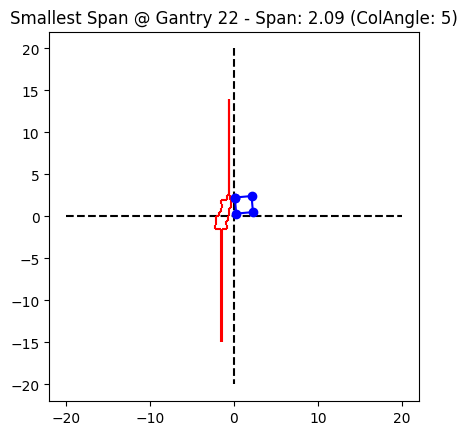

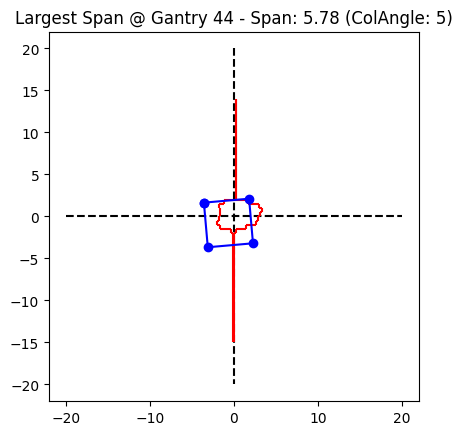

In [53]:
## plot max and min

# get all the values

field_rotated_list = []
cp_list = []
span_list = []

for n in range(len(varian_field.mq_control_points)):
    cp = varian_field.mq_control_points[n]

    X1 = cp['collimatorX1']
    X2 = cp['collimatorX2']
    collimatorAngle = math.radians(cp['collimatorAngle'])
    Y1 = max(cp['leafSetA'])
    Y2 = max(cp["leafSetB"])
    gantry = cp["gantryAngle"]


    field_rotated = span("TrueBeam", collimatorAngle, X1, X2, Y1 = Y1, Y2 = Y2)

    field_rotated_ordinate = [corner[1] for corner in field_rotated]
        
    span_val = max(field_rotated_ordinate) - min(field_rotated_ordinate)
        
    span_list.append(span_val)
    cp_list.append(n)
    field_rotated_list.append(field_rotated)

# find max and min
max_index = span_list.index(max(span_list))
max_span = span_list[max_index]
max_gantry = cp_list[max_index]
max_field_rotated = field_rotated_list[max_index]

min_index = span_list.index(min(span_list))
min_span = span_list[min_index]
min_gantry = cp_list[min_index]
min_field_rotated = field_rotated_list[min_index]

# Plot largest and smallest span
min_cp = varian_field.mq_control_points[min_gantry]

fig, ax = plt.subplots()
ax.plot([0, 0], [20, -20], '--', color='black')
ax.plot([-20, 20], [0, 0], '--', color='black') 
ax.set_aspect('equal')

plot_segment(min_cp,"TrueBeam",varian_field.leaf_width)

field_rotated_abscissa = [corner[0] for corner in min_field_rotated]
field_rotated_ordinate = [corner[1] for corner in min_field_rotated]
ax.plot(field_rotated_abscissa+[field_rotated_abscissa[0]], field_rotated_ordinate+[field_rotated_ordinate[0]], 'bo-')

plt.title("Smallest Span @ Gantry {} - Span: {:.2f} (ColAngle: {:.0f})".format(min_cp["gantryAngle"], min_span, min_cp['collimatorAngle']))

plt.show()

max_cp = varian_field.mq_control_points[max_gantry]

fig, ax = plt.subplots()
ax.plot([0, 0], [20, -20], '--', color='black')
ax.plot([-20, 20], [0, 0], '--', color='black') 
ax.set_aspect('equal')

plot_segment(max_cp,"TrueBeam",varian_field.leaf_width)

field_rotated_abscissa = [corner[0] for corner in max_field_rotated]
field_rotated_ordinate = [corner[1] for corner in max_field_rotated]
ax.plot(field_rotated_abscissa+[field_rotated_abscissa[0]], field_rotated_ordinate+[field_rotated_ordinate[0]], 'bo-')

plt.title("Largest Span @ Gantry {} - Span: {:.2f} (ColAngle: {:.0f})".format(max_cp["gantryAngle"], max_span, max_cp['collimatorAngle']))

plt.show()

## Create funciton for Calculating Max of a Field

In [54]:
def field_span(field):
    field_rotated_list = []
    cp_list = []
    span_list = []

    for n in range(len(field.mq_control_points)):
        cp = field.mq_control_points[n]

        X1 = cp['collimatorX1']
        X2 = cp['collimatorX2']
        collimatorAngle = math.radians(cp['collimatorAngle'])
        Y1 = max(cp['leafSetA'])
        Y2 = max(cp["leafSetB"])

        field_rotated = span(field.machine_type, collimatorAngle, X1, X2, Y1 = Y1, Y2 = Y2)

        field_rotated_ordinate = [corner[1] for corner in field_rotated]
            
        span_val = max(field_rotated_ordinate) - min(field_rotated_ordinate)
            
        span_list.append(span_val)
        cp_list.append(n)
        field_rotated_list.append(field_rotated)

    # find max and min
    max_index = span_list.index(max(span_list))
    max_span = span_list[max_index]

    return max_span


In [55]:
field_span(varian_field)

5.780358751666359

In [2]:
directory = os.path.dirname(os.getcwd()) +'\\Nov6\\'
spans = []
machine = []
for i in df["FieldID"]:
    file = directory+"FieldID_" + str(i) + '.json'
    field = Field(file)
    spans.append(field_span(field))
    if field.machine_type == "Agility":
        machine.append("Elekta")
    else:
        machine.append("Varian")

NameError: name 'os' is not defined

In [ ]:
df["Machine"] = machine
df["Span"] = spans

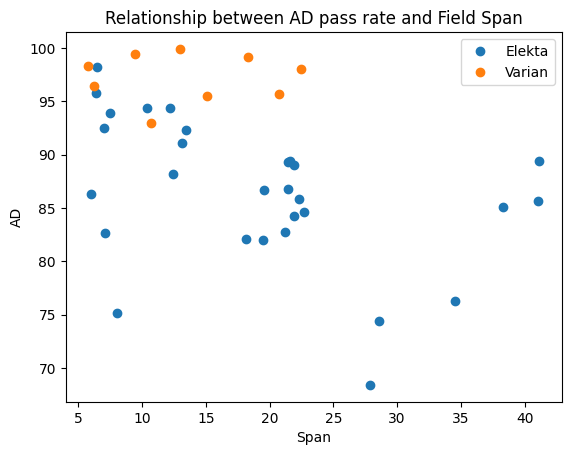

In [ ]:
import matplotlib.pyplot as plt
groups = df.groupby('Machine')

# Plot
fig, ax = plt.subplots()
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
for name, group in groups:
    ax.plot(group.Span, group.AD, marker='o', linestyle='', label=name)
ax.legend()
plt.xlabel("Span")
plt.ylabel("AD")
plt.title("Relationship between AD pass rate and Field Span")
plt.show()


In [ ]:
from math import cos, pi
field = Field("Nov6\\FieldID_2392762.json")

In [ ]:
def set_span(field):
    import math
    num_cp = len(field.mq_control_points)
    max_span = 0

    for i in range(num_cp):
        max_span = 0
        if field.machine_type == "Agility":
            Y1 = field.matrixA.max().max()
            Y2 = field.matrixB.max().max()
        else:
            Y1 = field.mq_control_points[0]["collimatorY1"]
            Y2 = field.mq_control_points[0]["collimatorY2"]
        X1 = field.mq_control_points[0]["collimatorX1"]
        X2 = field.mq_control_points[0]["collimatorX2"]
        collimatorAngle = field.mq_control_points[i]["collimatorAngle"]*math.pi/180
        if collimatorAngle > 180:
            collimatorAngle = 360 - collimatorAngle
        if X1 ==0 or X2 == 0:
            alpha1 = 0
            alpha2 = 0
        else:
            if field.machine_type == "Agility":
                alpha1 = math.atan(X1/Y2) #UR
                alpha2 = math.atan(X2/Y1) #BL
                alpha3 = math.atan(X1/Y1) #UL
                alpha4 = math.atan(X2/Y2) #BR
                R3 = math.sqrt(math.pow(X1,2)+math.pow(Y1,2)) #UL
                R4 = math.sqrt(math.pow(X2,2)+math.pow(Y2,2)) #BR
            else:
                alpha1 = math.atan(Y2/X1) #UR
                alpha2 = math.atan(Y1/X2) #BL
                alpha3 = math.atan(Y2/X2) #UL
                alpha4 = math.atan(Y1/X1) #BR
                R3 = math.sqrt(math.pow(X2,2)+math.pow(Y2,2)) #UL
                R4 = math.sqrt(math.pow(X1,2)+math.pow(Y1,2)) #BR
        
        R1 = math.sqrt(math.pow(X1,2)+math.pow(Y2,2)) #UR
        R2 = math.sqrt(math.pow(X2,2)+math.pow(Y1,2)) #BL
        
        UR = R1*math.sin(alpha1+collimatorAngle)
        BL = R2*math.sin(-(alpha2+collimatorAngle))
        UL = R3*math.sin(alpha3+collimatorAngle)
        BR = R4*math.sin(-(alpha4+collimatorAngle))

        span = max(UR, BL, UL, BR) - min(UR, BL, UL, BR)
        if span > max_span:
            max_span = span
    
    return max_span